In [1]:
import sys
sys.path.append('../')
from utils_models import *
from scipy.optimize import minimize


In [2]:
with open('../pickles/mesolve_wd1649_final_leakage.pkl', 'rb') as file:
    results_leakage = pickle.load(file)

with open('../pickles/mesolve_wd1649_final_computational_1em3.pkl', 'rb') as file:
    results_compu_1em3 = pickle.load(file)

with open('../pickles/mesolve_wd1649_final_computational_5em4.pkl', 'rb') as file:
    results_compu_5em4 = pickle.load(file)


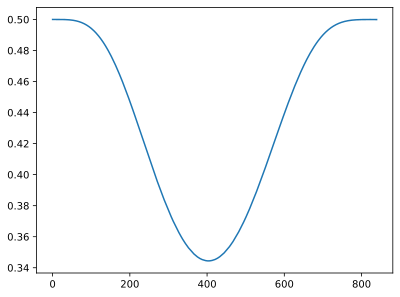

In [6]:
plt.plot([ abs(state[1,0]) for state in results_compu_5em4[2].states_dressed_to_2_level_dm])

In [5]:
max_ql = 20
max_ol = 50
system = FluxoniumOscillatorSystem(
    EJ = 2.33,
    EC = 0.69,
    EL = 0.12,
    Er = 7.16518677,
    g_strength = 0.18,
    qubit_level = max_ql,
    osc_level = max_ol,
    products_to_keep=[[ql, ol] for ql in [1,2] for ol in range(20) ]+ \
                    [[ql, ol] for ql in [9,10,11] for ol in range(12) ] ,    
    computaional_states = '1,2',
    )

In [34]:
type(system.osc.l_osc)

NoneType

In [11]:
subsystem_dims = [max(indexes) + 1 for indexes in zip(*system.product_to_dressed.keys())]
# Precompute indices as before
prod_dims_cumprod = np.cumprod(subsystem_dims[::-1])[::-1]
prod_dims_cumprod_shifted = np.roll(prod_dims_cumprod, shift=-1)
prod_dims_cumprod_shifted[-1] = 1

# Assuming product_to_dressed keys are tuples like (ql, ol), compute the index for each product state
indices_map = {pstate: sum(np.array(pstate) * prod_dims_cumprod_shifted) for pstate in system.product_to_dressed.keys()}


def convert_to_product(dm):
    if dm.isket:
        dm = qutip.ket2dm(dm)
    dressed_dm_data = dm.full()
    rho_product = np.zeros((np.prod(subsystem_dims), np.prod(subsystem_dims)), dtype=complex)

    # Now, instead of iterating and unpacking, directly use the dressed indices
    for product_state, dressed_index1 in system.product_to_dressed.items():
        index1 = indices_map[product_state]  # Use precomputed index
        for product_state2, dressed_index2 in system.product_to_dressed.items():
            index2 = indices_map[product_state2]  # Use precomputed index
            # Extract element directly without unpacking
            element = dressed_dm_data[dressed_index1, dressed_index2]
            rho_product[index1, index2] += element

    rho_product = qutip.Qobj(rho_product, dims=[subsystem_dims, subsystem_dims])
    return rho_product

In [12]:

def truncate_first_subsystem(rho):
    dim_1 = rho.dims[0][0]
    dim_2  =  rho.dims[0][1]
    rho_array = rho.full()
    rho_reshaped = rho_array.reshape((dim_1, dim_2, dim_1, dim_2))
    truncated_rho_reshaped = rho_reshaped[1:3, :, 1:3, :]
    truncated_rho_array = truncated_rho_reshaped.reshape((2 * dim_2, 2 * dim_2))
    truncated_rho = qutip.Qobj(truncated_rho_array, dims=[[2, dim_2], [2, dim_2]])
    return truncated_rho



def truncate_second_subsystem(rho,n):
    dim_1 = rho.dims[0][0]
    dim_2  =  rho.dims[0][1]
    if n >= dim_2:
        raise ValueError("n is out of bounds for the dimensionality of the second subsystem.")
    rho_array = rho.full()
    rho_reshaped = rho_array.reshape((dim_1, dim_2, dim_1, dim_2))
    truncated_rho_reshaped = rho_reshaped[:, n:n+1, :, n:n+1]
    # Reshape back to 2D array
    truncated_rho_array = truncated_rho_reshaped.reshape((dim_1, dim_1))
    # Create a new Qobj from the truncated array, adjusting the dimensions list to reflect the truncation
    truncated_rho = qutip.Qobj(truncated_rho_array, dims=[[dim_1], [dim_1]])
    return truncated_rho


In [20]:
t_idx = 50
truncate_second_subsystem( truncate_first_subsystem(convert_to_product(results_compu_5em4[2].states_pad_back_custom[t_idx])),0)


Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[0.48002342-3.48451768e-17j 0.21772511+4.27814409e-01j]
 [0.21772511-4.27814409e-01j 0.48003784+5.95032279e-18j]]

In [21]:
truncate_second_subsystem( truncate_first_subsystem(convert_to_product(results_compu_5em4[2].states_pad_back_custom[t_idx])),1)

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[0.01957236+3.32787471e-17j 0.00936798+1.71766041e-02j]
 [0.00936798-1.71766041e-02j 0.01955792-5.21531958e-18j]]

# Attemp 1: population-normalized sum of fidelity

In [12]:

def calc_weighted_infidelity_with_phase(theta,rho,state_ideal):
    dim_1 = rho.dims[0][0]
    dim_2  =  rho.dims[0][1]
    rho_array = rho.full().reshape((dim_1, dim_2, dim_1, dim_2))

    gate = qutip.Qobj(np.array([[1, 0],
                    [0, np.exp(1.0j * theta)]]))
    A = qutip.ket2dm(gate*state_ideal)
    sqrtmA = A.sqrtm()
    weights = np.real(np.diag(np.trace(rho_array, axis1=0, axis2=2)))
    fid_sum= 0.0 
    for ol in range(dim_2):
        B = qutip.Qobj(rho_array[:, ol, :, ol].reshape((dim_1, dim_1)), dims=[[dim_1], [dim_1]]).unit()
        eig_vals = (sqrtmA * B * sqrtmA).eigenenergies()
        fid = float(np.real(np.sqrt(eig_vals[eig_vals > 0]).sum()))
        fid_sum += fid * weights[ol]
    return 1 - fid_sum

zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
calc_weighted_infidelity_with_phase(0,truncate_first_subsystem(product_state),(zero +  one).unit())

 /Users/jiakaiwang/opt/miniconda3/envs/tensorflow/lib/python3.10/site-packages/scipy/sparse/_base.py: 653

0.6071600302448552

In [13]:
class WeightedInfidelityCalculator:
    def __init__(self):
        self.cache = {}

    def _cache_key(self, rho):
        # Use the memory addresses of rho and state_ideal as a simple cache key.
        # This approach assumes rho and state_ideal objects are not modified externally.
        return (id(rho))

    def _compute_pre_cached_values(self, rho):
        key = self._cache_key(rho)
        if key not in self.cache:
            rho_array = rho.full().reshape((rho.dims[0][0], rho.dims[0][1], rho.dims[0][0], rho.dims[0][1]))
            weights = np.real(np.diag(np.trace(rho_array, axis1=0, axis2=2)))
            dim_1, dim_2  = rho.dims[0]
            self.cache[key] = (rho_array,weights,dim_1,dim_2)
        return self.cache[key]

    def calc_weighted_infidelity_with_phase(self, theta, rho, state_ideal):
        rho_array,weights, dim_1, dim_2 = self._compute_pre_cached_values(rho)
        
        gate = qutip.Qobj(np.array([[1, 0], [0, np.exp(1.0j * theta)]]))
        # state_ideal_with_phase = gate*state_ideal
        A = qutip.ket2dm(gate*state_ideal)
        sqrtmA = A.sqrtm()
        fid_sum = 0.0

        for ol in range(dim_2):
            # normalized_level = qutip.Qobj(rho_array[:, ol, :, ol].reshape((dim_1, dim_1)), dims=[[dim_1], [dim_1]]).unit()
            # fid = qutip.fidelity(state_ideal_with_phase,normalized_level)
            B = qutip.Qobj(rho_array[:, ol, :, ol].reshape((dim_1, dim_1)), dims=[[dim_1], [dim_1]])/ weights[ol]
            eig_vals = (sqrtmA * B * sqrtmA).eigenenergies()
            fid = float(np.real(np.sqrt(eig_vals[eig_vals > 0]).sum()))
            fid_sum += fid * weights[ol]
        return 1 - fid_sum

# Example usage:
calculator = WeightedInfidelityCalculator()
calculator.calc_weighted_infidelity_with_phase(0,truncate_first_subsystem(product_state),(zero +  one).unit())

0.6071600302448552

In [15]:
tot_time = 840
tlist = np.linspace(0, tot_time, tot_time)



num_time_steps = tot_time

zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - 1j * one).unit(),
                ]


infidelity1 = []
phase1 = []
for idx in tqdm(range(num_time_steps)):
    calculator = WeightedInfidelityCalculator()
    dms = [result.states_pad_back_custom[idx] for result in results_compu_1em3[:4]]
    dms_two_lvl = [truncate_first_subsystem(convert_to_product(dm)) for dm in dms]
    def objective_function(phase):
        infidelities = [calculator.calc_weighted_infidelity_with_phase(phase[0],
                                                            dm_two_lvl,
                                                            state_ideal)  for dm_two_lvl, state_ideal in zip(dms_two_lvl,states_ideal)]
        mean = np.mean(infidelities)
        # print(f"evaluated at y = {mean}")
        return mean
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity1.append(opt_result.fun)
    phase1.append(opt_result.x[0])


infidelity2 = []
phase2 = []
for idx in tqdm(range(num_time_steps)):
    calculator = WeightedInfidelityCalculator()
    dms = [result.states_pad_back_custom[idx] for result in results_compu_5em4[:4]]
    dms_two_lvl = [truncate_first_subsystem(convert_to_product(dm)) for dm in dms]
    def objective_function(phase):
        infidelities = [calculator.calc_weighted_infidelity_with_phase(phase[0],
                                                            dm_two_lvl,
                                                            state_ideal)  for dm_two_lvl, state_ideal in zip(dms_two_lvl,states_ideal)]
        mean = np.mean(infidelities)
        # print(f"evaluated at y = {mean}")
        return mean
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity2.append(opt_result.fun)
    phase2.append(opt_result.x[0])



100%|██████████| 840/840 [35:33<00:00,  2.54s/it]


Text(0.5, 0, 'ns')

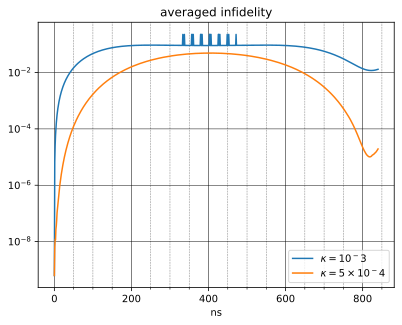

In [16]:
plt.plot(tlist,infidelity1,label = rf'$\kappa = 10^{-3}$')
plt.plot(tlist,infidelity2,label = rf'$\kappa = 5 \times 10^{-4}$')

plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

plt.legend()

plt.yscale('log')
plt.title("averaged infidelity")
plt.xlabel("ns")

# Attemp 2: population-normalized sum of fidelity with different phase for different levels

In [11]:
class WeightedInfidelityCalculatorV2:
    def __init__(self):
        self.cache = {}

    def _cache_key(self, rho):
        return (id(rho))

    def _compute_pre_cached_values(self, rho):
        key = self._cache_key(rho)
        if key not in self.cache:
            rho_array = rho.full().reshape((rho.dims[0][0], rho.dims[0][1], rho.dims[0][0], rho.dims[0][1]))
            weights = np.real(np.diag(np.trace(rho_array, axis1=0, axis2=2)))
            dim_1, dim_2  = rho.dims[0]
            self.cache[key] = (rho_array,weights,dim_1,dim_2)
        return self.cache[key]

    def calc_weighted_infidelity_with_phase(self, theta, rho, state_ideal):
        rho_array,weights, dim_1, dim_2 = self._compute_pre_cached_values(rho)
        
        fid_sum = 0.0
        for ol in range(5):
            gate = qutip.Qobj(np.array([[1, 0], [0, np.exp(1.0j * theta[ol])]]))
            A = qutip.ket2dm(gate*state_ideal)
            sqrtmA = A.sqrtm()
            B = qutip.Qobj(rho_array[:, ol, :, ol].reshape((dim_1, dim_1)), dims=[[dim_1], [dim_1]])/ weights[ol]
            eig_vals = (sqrtmA * B * sqrtmA).eigenenergies()
            fid = float(np.real(np.sqrt(eig_vals[eig_vals > 0]).sum()))
            fid_sum += fid * weights[ol]
        return 1 - fid_sum

In [69]:
tot_time = 840
tlist = np.linspace(0, tot_time, tot_time)
new_tlist = tlist[::5]
num_time_steps = len(new_tlist)

zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [
                zero,
                one,
                (zero +  one).unit(),
                (zero - 1j * one).unit(),
                ]


infidelity1 = []
phase1 = []
for idx in tqdm(range(num_time_steps)):
    calculator = WeightedInfidelityCalculatorV2()
    dms = [result.states_pad_back_custom[idx*5] for result in results_compu_1em3[:4]]
    dms_two_lvl = [truncate_first_subsystem(convert_to_product(dm)) for dm in dms]
    def objective_function(x):
        infidelities = [calculator.calc_weighted_infidelity_with_phase(x,
                                                            dm_two_lvl,
                                                            state_ideal)  for dm_two_lvl, state_ideal in zip(dms_two_lvl,states_ideal)]
        mean = np.mean(infidelities)
        # print(f"evaluated at y = {mean}")
        return mean
    x0 = [0.0 for _ in range(5)]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, x0,method="COBYLA")
    infidelity1.append(opt_result.fun)
    phase1.append(opt_result.x)

# with open('../pickles/optimize_ol_phases.pkl', 'wb') as file:
#     pickle.dump((infidelity1,phase1), file)


100%|██████████| 168/168 [21:25<00:00,  7.65s/it]/lib/python3.10/site-packages/scipy/sparse/_base.py: 653


In [16]:
with open('../pickles/optimize_ol_phases.pkl', 'rb') as file:
    infidelity1,phase1 =  pickle.load( file)

Text(0.5, 0, 'ns')

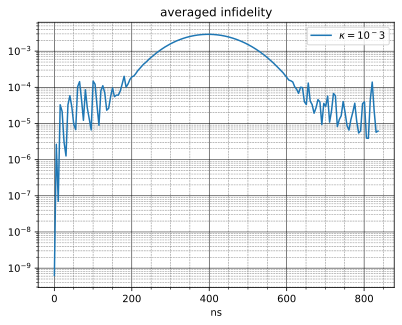

In [96]:
plt.plot(new_tlist,infidelity1,label = rf'$\kappa = 10^{-3}$')

plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

plt.legend()

plt.yscale('log')
plt.title("averaged infidelity")
plt.xlabel("ns")

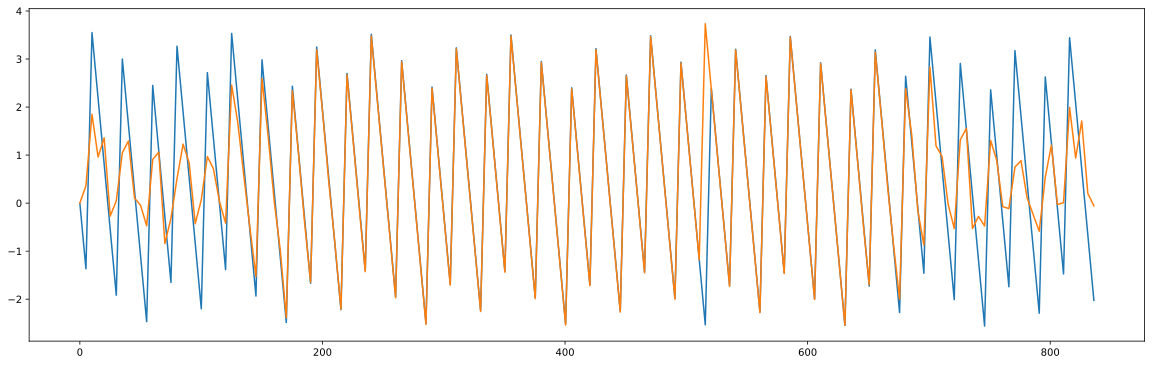

In [80]:
plt.figure(figsize=(20,6))

phase_list = np.array(phase1).transpose()
plt.plot(new_tlist,phase_list[0],label = rf'{0}')
plt.plot(new_tlist,phase_list[3],label = rf'{3}')


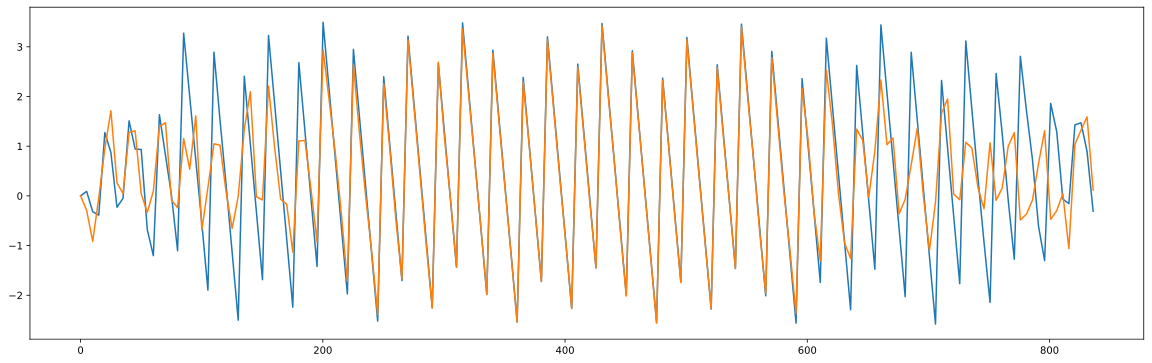

In [88]:
plt.figure(figsize=(20,6))

phase_list = np.array(phase1).transpose()
plt.plot(new_tlist,phase_list[2],label = rf'{2}')
plt.plot(new_tlist,phase_list[4],label = rf'{4}')


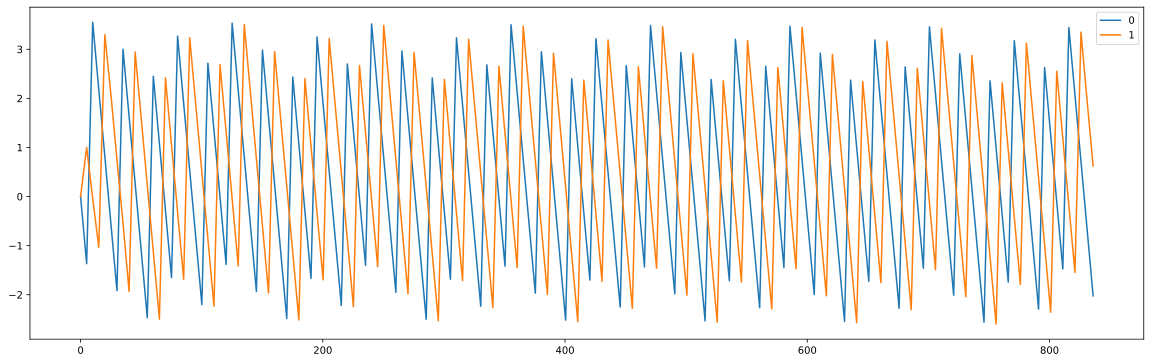

In [99]:
plt.figure(figsize=(20,6))

phase_list = np.array(phase1).transpose()
plt.plot(new_tlist,phase_list[0],label = rf'{0}')
plt.plot(new_tlist,phase_list[1],label = rf'{1}')
plt.legend()

In [17]:
phase_list = np.array(phase1).transpose()
phase_list.shape

(5, 168)

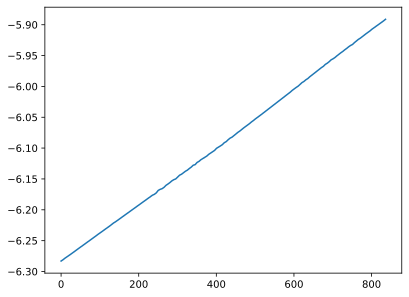

In [27]:
evals = system.qbt.eigenvals()
omega =  -1 *(evals[2]-evals[1])*2*np.pi
resid = (np.array(phase_list[0]) - np.array(omega*tlist[::5]))%(2*np.pi) - 2*np.pi
plt.plot(tlist[::5],resid)

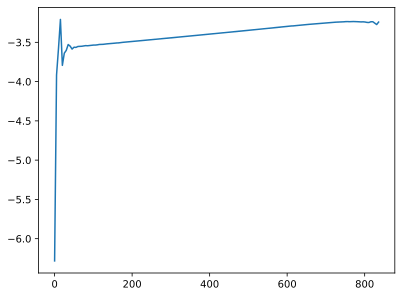

In [28]:
evals = system.qbt.eigenvals()
omega =  -1 *(evals[2]-evals[1])*2*np.pi
resid = (np.array(phase_list[1]) - np.array(omega*tlist[::5]))%(2*np.pi) - 2*np.pi
plt.plot(tlist[::5],resid)

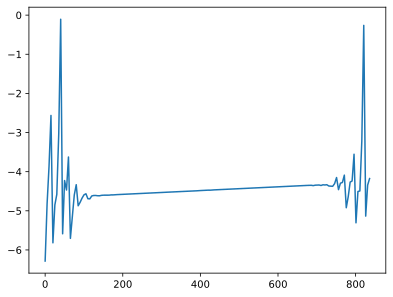

In [29]:
evals = system.qbt.eigenvals()
omega =  -1 *(evals[2]-evals[1])*2*np.pi
resid = (np.array(phase_list[2]) - np.array(omega*tlist[::5]))%(2*np.pi) - 2*np.pi
plt.plot(tlist[::5],resid)

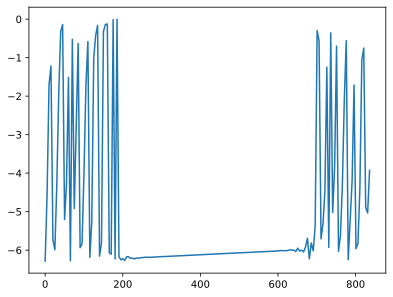

In [30]:
evals = system.qbt.eigenvals()
omega =  -1 *(evals[2]-evals[1])*2*np.pi
resid = (np.array(phase_list[3]) - np.array(omega*tlist[::5]))%(2*np.pi) - 2*np.pi
plt.plot(tlist[::5],resid)

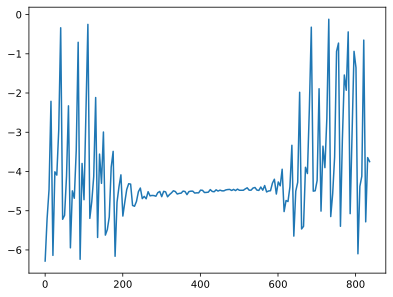

In [31]:
evals = system.qbt.eigenvals()
omega =  -1 *(evals[2]-evals[1])*2*np.pi
resid = (np.array(phase_list[4]) - np.array(omega*tlist[::5]))%(2*np.pi) - 2*np.pi
plt.plot(tlist[::5],resid)

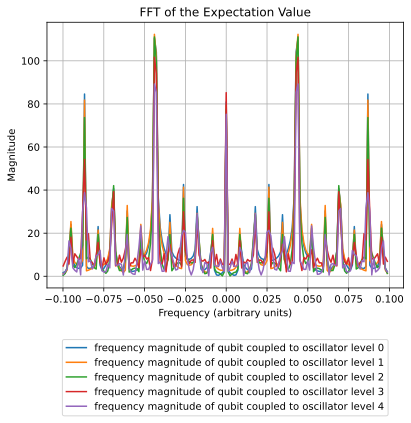

In [60]:
for i,phase in enumerate(np.array(phase1).transpose()):
    expectation_fft = np.fft.fft(phase)
    frequencies = np.fft.fftfreq(len(new_tlist), d=(new_tlist[1] - new_tlist[0]))  # assuming tlist is uniformly spaced

    fft_shifted = np.fft.fftshift(expectation_fft)
    frequencies_shifted = np.fft.fftshift(frequencies)
    plt.plot(frequencies_shifted, np.abs(fft_shifted),label = f"frequency magnitude of qubit coupled to oscillator level {i}")
plt.xlabel('Frequency (arbitrary units)')
plt.ylabel('Magnitude')
plt.title('FFT of the Expectation Value')
plt.grid(True)
plt.legend(
    loc='lower center', 
    bbox_to_anchor=(0.5, -0.5), 
    ncol=1, 
    frameon=True, 
)

In [3]:
tot_time = 840
tlist = np.linspace(0, tot_time, tot_time)

num_time_steps = tot_time

zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - 1j * one).unit(),
                ]


def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(new_dm, dm_ideal))
        # fid.append(qutip.fidelity(dm, gate*dm_ideal))
    return 1-sum(fid)/len(fid)


from scipy.optimize import minimize

infidelity1 = []
phase1 = []
for idx in tqdm(range(num_time_steps)):
    dms = [result.states_dressed_to_2_level_dm[idx] for result in results_compu_1em3[:4]]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity1.append(opt_result.fun)
    phase1.append(opt_result.x[0])


# infidelity2 = []
# phase2 = []
# for idx in tqdm(range(num_time_steps)):
#     dms = [result.states_dressed_to_2_level_dm[idx] for result in results_compu_5em4[:4]]
#     def objective_function(phase):
#         return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
#     initial_phase = [0.0]
#     bounds = [(0, 2 * 3.141592653589793)]
#     opt_result = minimize(objective_function, initial_phase,method="COBYLA")
#     infidelity2.append(opt_result.fun)
#     phase2.append(opt_result.x[0])



100%|██████████| 840/840 [00:25<00:00, 32.97it/s]


Text(0.5, 0, 'ns')

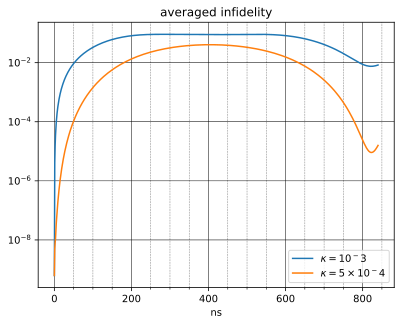

In [64]:
plt.plot(tlist,infidelity1,label = rf'$\kappa = 10^{-3}$')
plt.plot(tlist,infidelity2,label = rf'$\kappa = 5 \times 10^{-4}$')

plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

plt.legend()

plt.yscale('log')
plt.title("averaged infidelity")
plt.xlabel("ns")

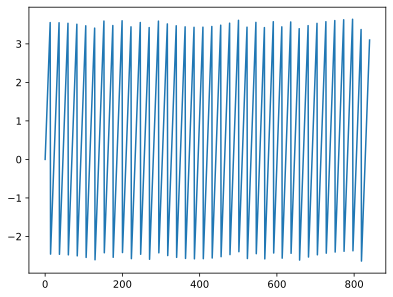

In [94]:
plt.plot(tlist,phase1)

In [24]:
evals = system.qbt.eigenvals()
(evals[2]-evals[1])*200

8.704470147995114

In [14]:
evals = system.qbt.eigenvals()
omega = (evals[2]-evals[1])*2*np.pi
resid = (np.array(phase1) - np.array(omega*tlist))%(2*np.pi) - 2*np.pi

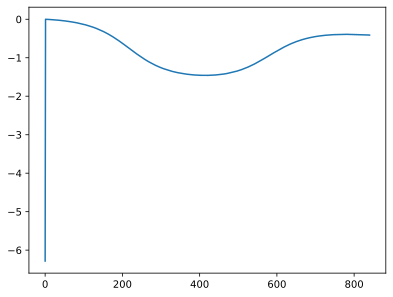

In [15]:
plt.plot(tlist,resid)

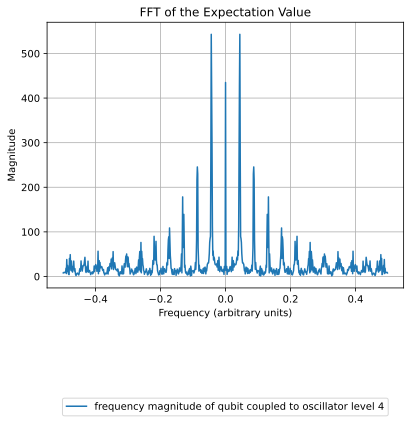

In [67]:
phase_fft = np.fft.fft(phase1)
frequencies = np.fft.fftfreq(len(tlist), d=(tlist[1] - tlist[0]))  # assuming tlist is uniformly spaced

fft_shifted = np.fft.fftshift(phase_fft)
frequencies_shifted = np.fft.fftshift(frequencies)
plt.plot(frequencies_shifted, np.abs(fft_shifted),label = f"frequency magnitude of qubit coupled to oscillator level {i}")
plt.xlabel('Frequency (arbitrary units)')
plt.ylabel('Magnitude')
plt.title('FFT of the phase Value')
plt.grid(True)
plt.legend(
    loc='lower center', 
    bbox_to_anchor=(0.5, -0.5), 
    ncol=1, 
    frameon=True, 
)

Processing through tlist: 100%|██████████| 840/840 [00:02<00:00, 397.59it/s]es/matplotlib/cbook/__init__.py: 1335


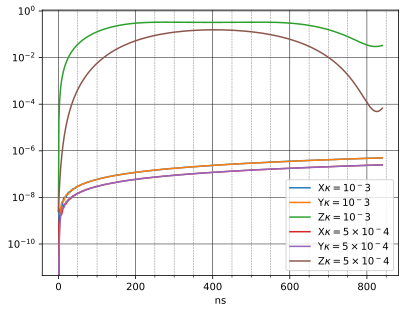

In [12]:
# colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
# linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
times = tlist
for pauli_results, phase, prefix in zip(
    [[results_compu_1em3[0],results_compu_1em3[1],results_compu_1em3[-2],results_compu_1em3[-1]], [results_compu_5em4[0],results_compu_5em4[1],results_compu_5em4[-2],results_compu_5em4[-1]]],
    [phase1,phase2],
    [rf'$\kappa = 10^{-3}$', rf'$\kappa = 5 \times 10^{-4}$']
    ):
    errors = {
        'X': [],
        'Y': [],
        'Z': []
    }
    inner_product_vals_dict = {
        'X': [],
        'Y': [],
        'Z': []
    }

    Paulis = [qutip.sigmax(),qutip.sigmay(),qutip.sigmaz()]


    dms_ideal = [
        zero * zero.dag(),
        one * one.dag(),
        zero * one.dag(),
        one * zero.dag()
    ]
    for idx in tqdm(range(len(times)), desc='Processing through tlist'):
        dms = [pauli_results[0].states_dressed_to_2_level_dm[idx],
            pauli_results[1].states_dressed_to_2_level_dm[idx],
            pauli_results[2].states_dressed_to_2_level_dm[idx],
            pauli_results[3].states_dressed_to_2_level_dm[idx]]
        gate = qutip.qip.operations.phasegate(theta=  phase[idx])
        for P, Pauli in zip(['X','Y','Z'],Paulis):
            inner_product_vals = []
            for dm_ideal, dm in zip(
                dms_ideal,
                [dms[0],dms[1],dms[2],dms[3]]
                ):
                the_second_term = Pauli * dm_ideal * Pauli.dag()                    
                dm = gate * dm * gate.dag()
                inner_product = (the_second_term * dm.dag()).tr()
                inner_product_vals.append(inner_product)
            errors[P].append(sum(inner_product_vals)/len(inner_product_vals))
            inner_product_vals_dict[P].append(inner_product_vals)

    plt.plot(times,errors['X'],label = 'X' + prefix)
    plt.plot(times,errors['Y'],label = 'Y' + prefix)
    plt.plot(times,errors['Z'],label = 'Z' + prefix)


plt.xlabel("ns")
plt.yscale('log')

plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

plt.legend()


# too long .

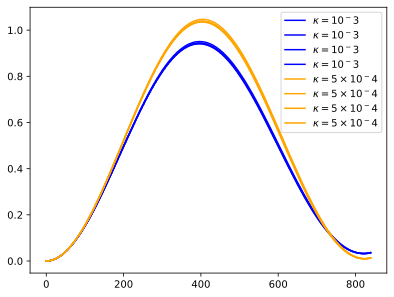

In [13]:
for computational_results, prefix, color in zip(
    [results_compu_1em3[:4], results_compu_5em4[:4]],
    [rf'$\kappa = 10^{-3}$', rf'$\kappa = 5 \times 10^{-4}$'],
    ['blue','orange']
    ):
    for result in computational_results:
        plt.plot(result.expect[1],color = color,label = prefix)
plt.legend()

    

(800.0, 840.0)

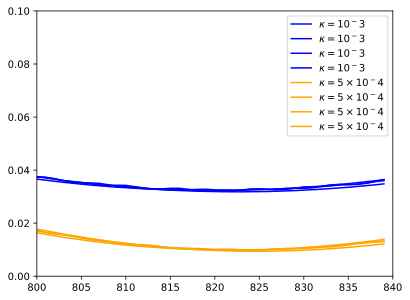

In [27]:
for computational_results, prefix, color in zip(
    [results_compu_1em3[:4], results_compu_5em4[:4]],
    [rf'$\kappa = 10^{-3}$', rf'$\kappa = 5 \times 10^{-4}$'],
    ['blue','orange']
    ):
    for result in computational_results:
        plt.plot(result.expect[1],color = color,label = prefix)
plt.legend()
plt.ylim(0,0.1)
plt.xlim(800,840)

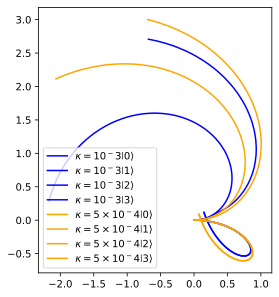

In [15]:
for eigenstate_results, prefix, color in zip(
    [[results_leakage[0],results_compu_1em3[0],results_compu_1em3[1],results_leakage[1]], [results_leakage[2],results_compu_5em4[0],results_compu_5em4[1],results_leakage[3]]],
    [rf'$\kappa = 10^{-3}$', rf'$\kappa = 5 \times 10^{-4}$'],
    ['blue','orange']
    ):
    first_dominant_freq =find_dominant_frequency(eigenstate_results[0].expect[0],tlist)
    for i, result in enumerate(eigenstate_results):
        alpha = result.expect[0]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
        plt.plot(-alpha.imag,alpha.real,color=color,label = prefix + rf'$\left|{i}\right>$')
plt.legend()
plt.gca().set_aspect('equal', 'box')

In [18]:
def plot_three_outcome_contrast(alpha_comput , alpha_leakage, alpha_leakage2, tlist,kappa_val):

    first_dominant_freq =find_dominant_frequency(alpha_leakage,tlist)
    alpha1 = alpha_comput*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    alpha0 = alpha_leakage*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    alpha3 = alpha_leakage2*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)

    plt.figure(figsize=(3+3/8,3+3/8))
    
    squared_diff = np.square(abs(alpha0-alpha1))
    integrals = [0.0]
    for i in range(1,len(tlist)):
        integrals.append(integrals[i-1]+
                            (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                            )
        
    plt.plot(tlist,integrals,label='1-0 contrast')

    squared_diff = np.square(abs(alpha3-alpha1))
    integrals = [0.0]
    for i in range(1,len(tlist)):
        integrals.append(integrals[i-1]+
                            (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                            )
        
    plt.plot(tlist,integrals,label='1-3 contrast')


    squared_diff = np.square(abs(alpha3-alpha0))
    integrals = [0.0]
    for i in range(1,len(tlist)):
        integrals.append(integrals[i-1]+
                            (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                            )
        
    plt.plot(tlist,integrals,label='0-3 contrast')



    plt.legend(loc='lower right')
    plt.yscale('log')
    plt.ylim(0,1e3)
    plt.yticks([1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1,1e1,1e2])
    plt.xlim(0,tot_time)
    plt.grid()
    plt.tight_layout()
    plt.xlabel('t')
    plt.ylabel('integrated contrast')
    # plt.savefig("fig06_integral.pdf", format='pdf', bbox_inches='tight')
    plt.show()



 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_9872/4215195642.py: 42

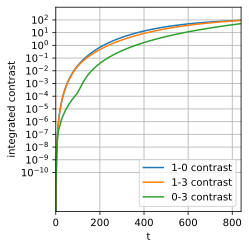

In [20]:
plot_three_outcome_contrast(alpha_comput =  results_compu_1em3[0].expect[-2],
                             alpha_leakage = results_leakage[0].expect[-2], 
                             alpha_leakage2 = results_leakage[1].expect[-2], 
                             tlist = tlist,
                             kappa_val = 1e-3)


 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_9872/4215195642.py: 42

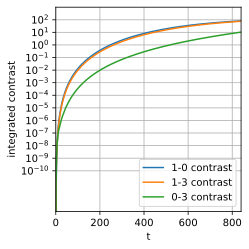

In [21]:
plot_three_outcome_contrast(alpha_comput =  results_compu_5em4[0].expect[-2],
                             alpha_leakage = results_leakage[2].expect[-2], 
                             alpha_leakage2 = results_leakage[3].expect[-2], 
                             tlist = tlist,
                             kappa_val =  5e-4)

In [59]:
def plot_three_outcome_integrated_signal(alpha_comput , alpha_leakage, alpha_leakage2, tlist,kappa_val,tidx_start,tidx_stop):

    first_dominant_freq =find_dominant_frequency(alpha_leakage,tlist)
    alphas = [
        alpha_comput*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist),
        alpha_leakage*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist),
        alpha_leakage2*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    ]

    integrals = []
    for alpha in alphas:
        integral  = 0.0 + 0j
        for idx in range(tidx_start+1,tidx_stop):
            integral += alpha[idx] * (tlist[i]-tlist[i-1])
        integral *= np.sqrt(kappa_val)
        integrals.append(integral)
    
    fig, ax = plt.subplots(figsize=(3+3/8,3+3/8))
    for integral, label,color in zip(integrals, ['1','0','3'], ['r','b','g']):
        print(integral)
        circle = plt.Circle((-integral.imag, integral.real), 1/np.sqrt(2), edgecolor=color, facecolor='none', label = label)
        ax.add_patch(circle)
    ax.set_xlim(-40,40)
    ax.set_ylim(-40,40)
    ax.legend(loc='lower right')
    ax.set_aspect('equal')
    plt.tight_layout()
    # plt.savefig("fig06_integral.pdf", format='pdf', bbox_inches='tight')
    plt.show()


# The radius of the integral signal shouldn't be the radius of the vacuum noise of a coherent state

(-1.4261982681209338-1.4273168169916794j)
(11.455943171443263+5.372227095907134j)
(13.1993651419478-0.35023836018466475j)


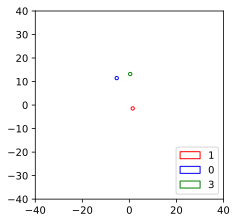

In [66]:

plot_three_outcome_integrated_signal(alpha_comput =  results_compu_5em4[0].expect[-2],
                             alpha_leakage = results_leakage[2].expect[-2], 
                             alpha_leakage2 = results_leakage[3].expect[-2], 
                             tlist = tlist,
                             kappa_val =  5e-4,
                             tidx_start = 600,
                             tidx_stop = 825)


In [8]:
max_ql = 20
max_ol = 50
system = FluxoniumOscillatorSystem(
    EJ = 2.33,
    EC = 0.69,
    EL = 0.12,
    Er = 7.16518677,
    g_strength = 0.18,
    qubit_level = max_ql,
    osc_level = max_ol,
    products_to_keep=[[ql, ol] for ql in [1,2] for ol in range(3) ],
    computaional_states = '1,2',
    )

evals, evecs = system.hilbertspace.hamiltonian().eigenstates()
overlap_matrix = scqubits.utils.spectrum_utils.convert_evecs_to_ndarray(evecs)
def print_top_two_dressed_state(product_index):
    overlaps_with_product_state = np.abs(overlap_matrix[:, product_index])
    sorted_indices = np.argsort(overlaps_with_product_state)[::-1]
    sorted_overlaps = overlaps_with_product_state[sorted_indices]
    print(list(sorted_indices)[:2])
    print(list(sorted_overlaps)[:2])


for i in range(40):
    product_index_q0 = 0 * system.osc.truncated_dim + i
    product_index_q1 = 1 * system.osc.truncated_dim + i
    product_index_q2 = 2 * system.osc.truncated_dim + i

    overlaps_with_product_state_q0 = np.abs(overlap_matrix[:, product_index_q0])
    sorted_indices_q0 = np.argsort(overlaps_with_product_state_q0)[::-1]
    sorted_overlaps_q0 = overlaps_with_product_state_q0[sorted_indices_q0]
    overlaps_with_product_state_q1 = np.abs(overlap_matrix[:, product_index_q1])
    sorted_indices_q1 = np.argsort(overlaps_with_product_state_q1)[::-1]
    sorted_overlaps_q1 = overlaps_with_product_state_q1[sorted_indices_q1]
    overlaps_with_product_state_q2 = np.abs(overlap_matrix[:, product_index_q2])
    sorted_indices_q2 = np.argsort(overlaps_with_product_state_q2)[::-1]
    sorted_overlaps_q2 = overlaps_with_product_state_q2[sorted_indices_q2]

    print(f"ol-{i}:\t{list(sorted_indices_q0)[0]}-{list(sorted_overlaps_q0)[0]**2:.3f} \t {list(sorted_indices_q1)[0]}-{list(sorted_overlaps_q1)[0]**2:.3f} \t {list(sorted_indices_q2)[0]}-{list(sorted_overlaps_q2)[0]**2:.3f}")


ol-0:	0-1.000 	 1-1.000 	 2-1.000
ol-1:	7-0.978 	 12-0.999 	 13-0.998
ol-2:	24-0.958 	 31-0.999 	 32-0.997
ol-3:	44-0.938 	 51-0.998 	 52-0.996
ol-4:	64-0.919 	 71-0.997 	 72-0.994
ol-5:	84-0.901 	 91-0.997 	 92-0.993
ol-6:	104-0.883 	 111-0.996 	 112-0.991
ol-7:	124-0.866 	 131-0.996 	 132-0.990
ol-8:	144-0.850 	 151-0.995 	 152-0.988
ol-9:	164-0.834 	 171-0.994 	 172-0.987
ol-10:	184-0.819 	 191-0.994 	 192-0.985
ol-11:	204-0.805 	 211-0.993 	 212-0.984
ol-12:	224-0.791 	 231-0.993 	 232-0.982
ol-13:	244-0.777 	 251-0.992 	 252-0.981
ol-14:	264-0.764 	 271-0.991 	 272-0.979
ol-15:	284-0.752 	 291-0.991 	 292-0.978
ol-16:	304-0.740 	 311-0.990 	 312-0.976
ol-17:	324-0.728 	 331-0.990 	 332-0.975
ol-18:	344-0.716 	 351-0.989 	 352-0.973
ol-19:	364-0.705 	 371-0.988 	 372-0.972
ol-20:	384-0.695 	 391-0.988 	 392-0.970
ol-21:	404-0.684 	 411-0.987 	 412-0.968
ol-22:	424-0.674 	 431-0.987 	 432-0.967
ol-23:	444-0.664 	 451-0.986 	 452-0.965
ol-24:	464-0.655 	 471-0.985 	 472-0.964
ol-25:	

In [94]:
osc_lvls = 100
w_q = 0.1
delta_q = 0.0001
delta_o = 0.02
w_o = 40

t_tot = 1000
diag = []
for i in range(osc_lvls):
    diag.append(9+i*w_o+i*delta_o)
    diag.append(9+i*w_o+i*delta_o + i * delta_q)
H_diag = qutip.Qobj(np.diag(diag),dims = [[osc_lvls,2],[osc_lvls,2]])

psi0 = qutip.tensor(qutip.basis(osc_lvls,0),(qutip.basis(2,0)+qutip.basis(2,1)).unit())
drive_term = qutip.tensor(qutip.create(N=osc_lvls) + qutip.destroy(N=osc_lvls),qutip.identity(2))

In [95]:
def drive(t,args):
    amp = 4e-3
    w_d = w_o
    return 2 * np.pi * amp * np.cos(w_d * t)

result = qutip.sesolve(psi0=psi0,
                       H = [
                        H_diag,
                        [drive_term, drive]],
                        tlist = np.linspace(0,t_tot,t_tot),
                        e_ops = [ qutip.tensor(qutip.create(N=osc_lvls),qutip.identity(2)) * qutip.tensor(qutip.destroy(N=osc_lvls),qutip.identity(2))],
                        options = qutip.Options(store_states=True, nsteps=80000, num_cpus=1),
                        progress_bar = qutip.ui.progressbar.EnhancedTextProgressBar(),
                       )

 [          0%           ] Elapsed 0.00s / Remaining 00:00:00:00

 Total run time: 162.53s*] Elapsed 162.53s / Remaining 00:00:00:00


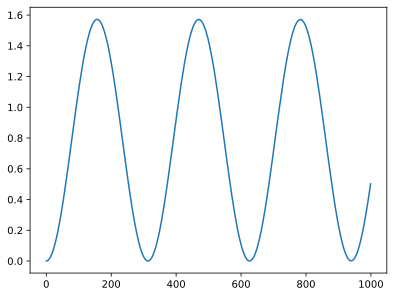

In [96]:
plt.plot(result.expect[0])

In [116]:
qutip.ket2dm(result.states[100])

Quantum object: dims = [[100, 2], [100, 2]], shape = (200, 200), type = oper, isherm = True
Qobj data =
[[ 1.63210483e-01+0.00000000e+00j  1.63538725e-01-2.09440743e-04j
  -8.66712511e-02-1.49367741e-01j ...  1.62257706e-04-4.18958424e-05j
   2.21543060e-04-1.14288025e-04j  2.18517515e-04+1.18956917e-04j]
 [ 1.63538725e-01+2.09440743e-04j  1.63867897e-01+0.00000000e+00j
  -8.66538841e-02-1.49779365e-01j ...  1.62637795e-04-4.17718836e-05j
   2.22135279e-04-1.14233581e-04j  2.18804337e-04+1.19476572e-04j]
 [-8.66712511e-02+1.49367741e-01j -8.66538841e-02+1.49779365e-01j
   1.82724953e-01+0.00000000e+00j ... -4.78228537e-05+1.70744131e-04j
  -1.30535123e-05+2.63444307e-04j -2.24909036e-04+1.36813043e-04j]
 ...
 [ 1.62257706e-04+4.18958424e-05j  1.62637795e-04+4.17718836e-05j
  -4.78228537e-05-1.70744131e-04j ...  1.72065079e-07+0.00000000e+00j
   2.49587287e-07-5.67511320e-08j  1.86705841e-07+1.74355539e-07j]
 [ 2.21543060e-04+1.14288025e-04j  2.22135279e-04+1.14233581e-04j
  -1.30535123

In [117]:
result.states[100].ptrace(1)

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[0.5       -2.32907977e-18j 0.49998702+2.15764899e-03j]
 [0.49998702-2.15764899e-03j 0.5       +3.96848864e-18j]]

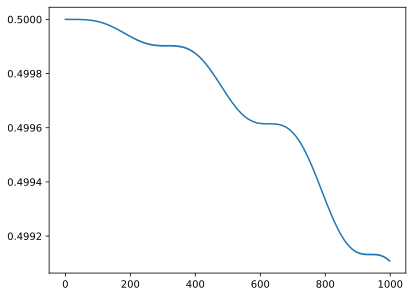

In [104]:
plt.plot([ abs(result.states[i].ptrace(1)[0,1]) for i in range(t_tot-1)])

In [109]:
result.states[230].ptrace(1)

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[0.49999996-4.80367015e-18j 0.49979877+1.09936985e-02j]
 [0.49979877-1.09936985e-02j 0.50000004+6.08336703e-18j]]

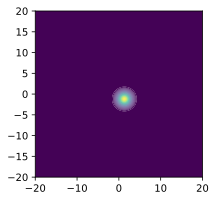

In [111]:
xvec = np.linspace(-20,20,500)
Q_fock = qutip.qfunc(result.states[160].ptrace(0), xvec, xvec)
fig, ax = plt.subplots(1, 1, figsize=(3,3))
cont0 = ax.contourf(xvec, xvec, Q_fock, 100)
plt.show()

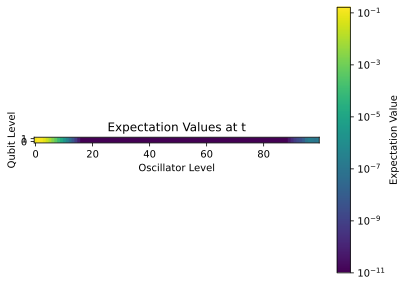

In [112]:


dm = result.states[150]


dm = qutip.ket2dm(dm)
dm = qutip.Qobj(dm.full())
dm = 0.5 * (dm + dm.dag())
dm = dm / dm.tr()
# dm = pad_back_function(dm)
grid = np.zeros(( 2,osc_lvls))
product_to_dressed = {}
for ol in range(osc_lvls):
    product_to_dressed[(ol,0)] = ol*2
    product_to_dressed[(ol,1)] = ol*2 + 1

for qubit_level in range(2):
    for oscillator_level in range(osc_lvls):
        product_state = (oscillator_level,qubit_level)
        dressed_state = product_to_dressed[product_state]
        if dressed_state < dm.dims[0][0]:
            # Create a basis state corresponding to the dressed state
            basis_state = qutip.basis(dm.dims[0][0], dressed_state)
            # Calculate the expectation value
            expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
        else:
            expectation_value = 0
        grid[ qubit_level,oscillator_level] = expectation_value
grid[grid < 1e-11] = 1e-11
plt.imshow(grid, cmap='viridis', origin='lower', norm=LogNorm())
plt.colorbar(label='Expectation Value')
plt.xlabel('Oscillator Level')
plt.ylabel('Qubit Level')
plt.title(f'Expectation Values at t')
plt.show()